🔄 Đang xử lý dữ liệu từ: /content/drive/MyDrive/Dữ liệu/BK_20_Test_3_clean.csv
   -> (Info) Input Smoothing: OFF (Giữ độ nhám thực tế)
📉 TỐC ĐỘ SUY GIẢM INPUT THỰC TẾ (%/tháng)
  -> Annulus pressure_avg: Xu hướng GIẢM. Tốc độ: 0.20%/tháng
  -> Flow pressure_avg: Xu hướng GIẢM. Tốc độ: 0.39%/tháng
  -> T_avg: Xu hướng GIẢM. Tốc độ: 0.69%/tháng


/tmp/ipykernel_661/2079366966.py:68: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Qliq'] = df['Qliq'].fillna(method='ffill').fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/tmp/ipykernel_661/2079366966.py:74: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Qliq'] = df['Qliq'].interpolate().fillna(method='bfill')


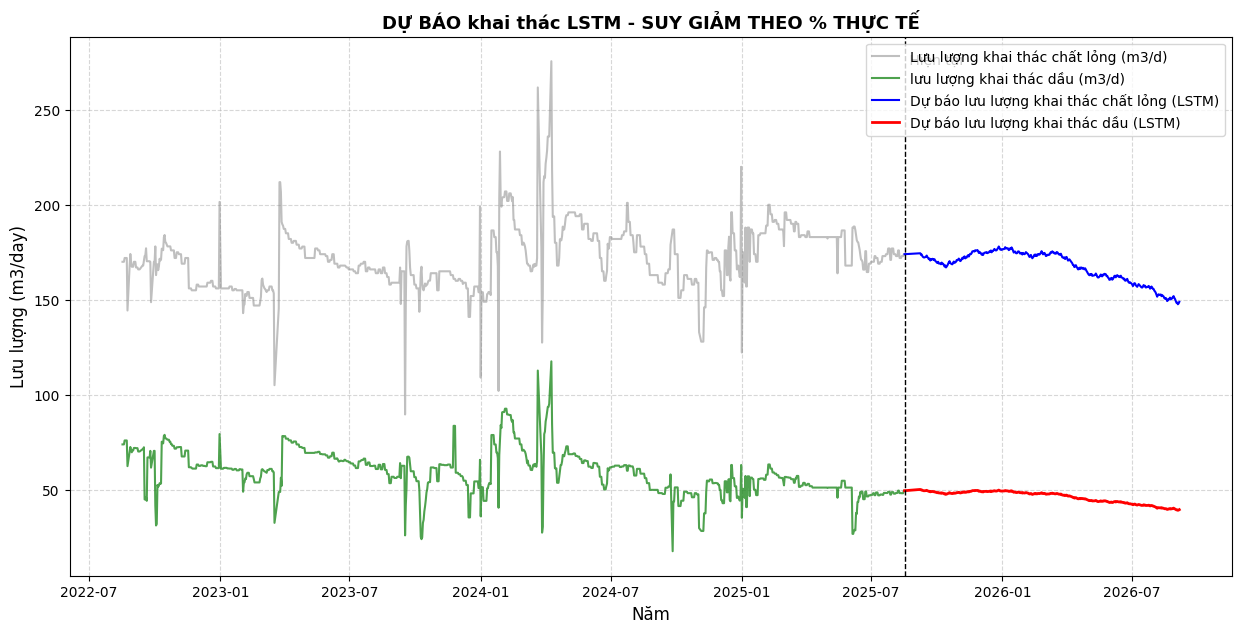


KẾT QUẢ DỰ BÁO CHI TIẾT THEO THÁNG (AVERAGE)
            Qliq_Forecast  Qoil_Forecast     OilCut
Date                                               
2025-09-30     172.149009      49.463990  28.732932
2025-10-31     169.218272      48.287674  28.535884
2025-11-30     173.597071      49.160049  28.319059
2025-12-31     175.542945      49.342932  28.109084
2026-01-31     175.829463      49.052666  27.897538
2026-02-28     173.748384      48.132407  27.702413
2026-03-31     173.832555      47.819038  27.508507
2026-04-30     167.927664      45.869464  27.314376
2026-05-31     162.760830      44.143209  27.121401
2026-06-30     161.181406      43.413808  26.934504
2026-07-31     157.199483      42.049025  26.748636
2026-08-31     151.768124      40.392010  26.614186
2026-09-30     148.514650      39.515840  26.607368


/tmp/ipykernel_661/2079366966.py:262: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_forecast.set_index('Date').resample('M').mean()


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from tensorflow.keras.models import load_model
from tensorflow.keras import layers

# 1. CẤU HÌNH & ĐƯỜNG DẪN
FORECAST_DURATION_DAYS = 365
TIMESTEPS = 120

# Đường dẫn file trên Google Drive của bạn
DATA_FILE   = "/content/drive/MyDrive/Dữ liệu/BK_20_Test_3_clean.csv"
OILCUT_FILE = "/content/drive/MyDrive/Dữ liệu/OilCut_Forecast_3Years_1095Days.csv"
MODEL_PATH  = "/content/drive/MyDrive/Colab Notebooks/Best_model_LSTM.keras"

# Cấu hình suy giảm Vật lý (15%/năm)
PHYSICAL_DECAY_YEARLY = 0.15
DAILY_DECAY_FACTOR = (1 - PHYSICAL_DECAY_YEARLY) ** (1/365)

FEATURE_SEQ = [
    'Annulus pressure_avg', 'Flow pressure_avg', 'T_avg',
    'Gas injection rate', 'Choke',
    'dQliq', 'dGI', 'dFlowP',
    'Qliq_ma7', 'Qliq_ma21',
    'drop_pct_3'
]
TARGET = 'Qliq'
IDX = {name: i for i, name in enumerate(FEATURE_SEQ)}
FIXED_VARS = ['Gas injection rate', 'Choke']
AUTO_DECLINE_VARS = ['Annulus pressure_avg', 'Flow pressure_avg', 'T_avg']

# 2. HÀM XỬ LÝ (NO SMOOTHING - DỮ LIỆU THÔ)
@tf.keras.utils.register_keras_serializable()
class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]), initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],), initializer='zeros', trainable=True)
        self.u = self.add_weight(shape=(input_shape[-1],1), initializer='glorot_uniform', trainable=True)
        super(AttentionLayer, self).build(input_shape)
    def call(self, inputs):
        v = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        vu = tf.tensordot(v, self.u, axes=1)
        alphas = tf.nn.softmax(vu, axis=1)
        output = tf.reduce_sum(inputs * alphas, axis=1)
        return output

def process_data_inference(filepath):
    print(f"🔄 Đang xử lý dữ liệu từ: {filepath}")
    df = pd.read_csv(filepath)
    pairs = [('Annulus pressure', 'Annulus pressure min', 'Annulus pressure max'),
             ('Buffer pressure', 'Buffer pressure min', 'Buffer pressure max'),
             ('Flow pressure', 'Flow pressure min', 'Flow pressure max'),
             ('T', 'T min', 'T max')]
    for name, col_min, col_max in pairs:
        if col_min in df.columns and col_max in df.columns:
            df[f'{name}_avg'] = (df[col_min] + df[col_max]) / 2

    if 'Qliq' in df.columns:
        df['Qliq'] = df['Qliq'].fillna(method='ffill').fillna(method='bfill')
        # Lọc nhiễu thô
        iso = IsolationForest(contamination=0.01, random_state=42)
        iso.fit(df[['Qliq']])
        outlier_labels = iso.predict(df[['Qliq']].values)
        df.loc[outlier_labels == -1, 'Qliq'] = np.nan
        df['Qliq'] = df['Qliq'].interpolate().fillna(method='bfill')

        # GIỮ NGUYÊN DỮ LIỆU THÔ (KHÔNG LÀM MƯỢT)
        df['Qliq_smooth'] = df['Qliq']
        print("   -> (Info) Input Smoothing: OFF (Giữ độ nhám thực tế)")

    df['dQliq'] = df['Qliq_smooth'].diff().fillna(0)
    df['dGI'] = df['Gas injection rate'].diff().fillna(0) if 'Gas injection rate' in df.columns else 0
    df['dFlowP'] = df['Flow pressure_avg'].diff().fillna(0) if 'Flow pressure_avg' in df.columns else 0
    df['Qliq_ma7'] = df['Qliq_smooth'].rolling(7, min_periods=1).mean()
    df['Qliq_ma21'] = df['Qliq_smooth'].rolling(21, min_periods=1).mean()
    df['drop_pct_3'] = df['Qliq_smooth'].pct_change(3).fillna(0)
    return df.dropna(subset=FEATURE_SEQ + [TARGET]).reset_index(drop=True)

def calculate_monthly_decline(series, lookback_days=180):
    if len(series) < lookback_days: lookback_days = len(series)
    y = series.iloc[-lookback_days:].values
    x = np.arange(len(y)).reshape(-1, 1)
    model = LinearRegression()
    model.fit(x, y)
    slope = model.coef_[0]
    current_val = y[-1]
    monthly_change = slope * 30
    if current_val == 0: return 0, slope
    decline_rate = -monthly_change / current_val
    return decline_rate, slope

# 3. CHUẨN BỊ INPUT & MODEL
if not os.path.exists(DATA_FILE): raise FileNotFoundError(f"Không tìm thấy file: {DATA_FILE}")
df_clean = process_data_inference(DATA_FILE)

# Auto Decline Calculation
print(f"📉 TỐC ĐỘ SUY GIẢM INPUT THỰC TẾ (%/tháng)")
INPUT_DECLINE_MONTHLY = {}
current_sim_values = {}
for var in AUTO_DECLINE_VARS:
    rate, slope = calculate_monthly_decline(df_clean[var], lookback_days=180)
    current_val = df_clean[var].iloc[-1]
    if rate < 0:
        print(f"  -> {var}: Xu hướng TĂNG. Gán suy giảm = 0%.")
        rate = 0.0
    else:
        print(f"  -> {var}: Xu hướng GIẢM. Tốc độ: {rate*100:.2f}%/tháng")
    INPUT_DECLINE_MONTHLY[var] = rate
    current_sim_values[var] = current_val

# Scalers
X_all = df_clean[FEATURE_SEQ].values
scalers = [MinMaxScaler() for _ in range(len(FEATURE_SEQ))]
scaler_y = MinMaxScaler()
for i in range(len(FEATURE_SEQ)): scalers[i].fit(X_all[:, i].reshape(-1, 1))
scaler_y.fit(df_clean[TARGET].values.reshape(-1, 1))
fixed_values = {var: df_clean[var].iloc[-1] for var in FIXED_VARS}

# Initial Sequence
last_raw_data = df_clean[FEATURE_SEQ].iloc[-TIMESTEPS:].values
current_sequence = np.zeros((TIMESTEPS, len(FEATURE_SEQ)))
for i in range(len(FEATURE_SEQ)):
    current_sequence[:, i] = scalers[i].transform(last_raw_data[:, i].reshape(-1, 1)).flatten()

# Model & OilCut
model = load_model(MODEL_PATH, custom_objects={'AttentionLayer': AttentionLayer})
df_oilcut = pd.read_csv(OILCUT_FILE)
df_oilcut['Date'] = pd.to_datetime(df_oilcut['Date'])
start_date = df_oilcut['Date'].iloc[0]
full_idx = pd.date_range(start=start_date, periods=FORECAST_DURATION_DAYS, freq='D')
# Dùng 'exp_pred'
oilcut_daily = df_oilcut.set_index('Date').reindex(full_idx)['hyperbolic_pred'].interpolate(method='time').ffill().bfill().values

# 4. VÒNG LẶP DỰ BÁO (NHIỄU +/- 2)
predicted_qliq = []
history_qliq = list(df_clean['Qliq_smooth'].iloc[-30:].values)
current_decay_factor = 1.0

# Seed để kết quả ngẫu nhiên nhưng tái lập được (nếu cần đổi nhiễu khác thì thay đổi số này)
np.random.seed(999)

for i in range(FORECAST_DURATION_DAYS):
    # 1. Predict (LSTM)
    input_tensor = current_sequence.reshape(1, TIMESTEPS, len(FEATURE_SEQ))
    pred_scaled = model.predict(input_tensor, verbose=0)[0][0]
    lstm_pred_val = max(0, scaler_y.inverse_transform([[pred_scaled]])[0][0])

    # 2. Physics Decay (Suy giảm vật lý)
    current_decay_factor *= DAILY_DECAY_FACTOR
    trend_val = lstm_pred_val * current_decay_factor

    # 3. Anti-Shock (Chặn tăng vọt so với hôm qua)
    # Lấy giá trị cơ bản (base) từ lịch sử để so sánh
    prev_val = history_qliq[-1]

    # Logic: Xu hướng chính không được phép lớn hơn hôm qua (trừ sai số nhỏ)
    if trend_val > prev_val:
        trend_val = prev_val * 0.9995

    # 4. --- THÊM NHIỄU (ADD NOISE +/- 2) ---
    # Cộng nhiễu vào giá trị xu hướng đã ổn định
    noise = np.random.uniform(-1,1)
    final_pred_val = trend_val + noise

    # Chặn không âm
    final_pred_val = max(0, final_pred_val)

    predicted_qliq.append(final_pred_val)

    # Update State (Lưu giá trị có nhiễu vào lịch sử để tạo dao động tiếp diễn)
    history_qliq.append(final_pred_val)
    new_row = current_sequence[-1].copy()

    # Update Inputs
    for var in AUTO_DECLINE_VARS:
        idx = IDX[var]
        rate = INPUT_DECLINE_MONTHLY[var]
        current_sim_values[var] *= (1 - rate/30.0)
        new_row[idx] = scalers[idx].transform([[current_sim_values[var]]])[0][0]

    for var in FIXED_VARS:
        idx = IDX[var]
        new_row[idx] = scalers[idx].transform([[fixed_values[var]]])[0][0]

    # Derived Features
    diff_q = final_pred_val - history_qliq[-2]
    new_row[IDX['dQliq']] = scalers[IDX['dQliq']].transform([[diff_q]])[0][0]
    new_row[IDX['dGI']] = 0

    old_flow_p = current_sim_values['Flow pressure_avg'] / (1 - INPUT_DECLINE_MONTHLY['Flow pressure_avg']/30.0)
    d_flow_p = current_sim_values['Flow pressure_avg'] - old_flow_p
    new_row[IDX['dFlowP']] = scalers[IDX['dFlowP']].transform([[d_flow_p]])[0][0]

    new_row[IDX['Qliq_ma7']] = scalers[IDX['Qliq_ma7']].transform([[np.mean(history_qliq[-7:])]])[0][0]
    new_row[IDX['Qliq_ma21']] = scalers[IDX['Qliq_ma21']].transform([[np.mean(history_qliq[-21:])]])[0][0]

    if len(history_qliq) >= 4:
        q_t3 = history_qliq[-4]
        pct = (final_pred_val - q_t3)/q_t3 if q_t3 > 0.1 else 0
    else: pct = 0
    new_row[IDX['drop_pct_3']] = scalers[IDX['drop_pct_3']].transform([[pct]])[0][0]

    current_sequence = np.vstack([current_sequence[1:], new_row])

# 5. KẾT QUẢ & BIỂU ĐỒ LIỀN MẠCH
df_forecast = pd.DataFrame({'Date': full_idx, 'Qliq_Forecast': predicted_qliq, 'OilCut': oilcut_daily})
df_forecast['Qoil_Forecast'] = df_forecast['Qliq_Forecast'] * (df_forecast['OilCut'] / 100.0)

# Load History
df_hist = pd.read_csv(DATA_FILE)
try: df_hist['Date'] = pd.to_datetime(df_hist['Date'], format='%d/%m/%Y')
except: df_hist['Date'] = pd.to_datetime(df_hist['Date'])
df_hist.sort_values('Date', inplace=True)
if 'Qliq' in df_hist.columns: df_hist['Qliq_Plot'] = df_hist['Qliq'].interpolate()
wc_col = next((c for c in df_hist.columns if 'water' in c.lower() and 'cut' in c.lower()), None)
df_hist['Qoil_Plot'] = df_hist['Qliq_Plot'] * ((100 - df_hist[wc_col])/100) if wc_col else df_hist['Qliq_Plot']

# Nối điểm cuối lịch sử vào đầu dự báo để vẽ liền mạch
last_hist_row = df_hist.iloc[-1]
connection_row = pd.DataFrame({
    'Date': [last_hist_row['Date']],
    'Qliq_Forecast': [last_hist_row['Qliq_Plot']],
    'Qoil_Forecast': [last_hist_row['Qoil_Plot']],
    'OilCut': [np.nan]
})
df_forecast_plot = pd.concat([connection_row, df_forecast], ignore_index=True)

# Lọc lịch sử 3 năm
last_hist_date = df_hist['Date'].iloc[-1]
df_hist_plot = df_hist[df_hist['Date'] >= (last_hist_date - pd.DateOffset(years=3))]

plt.figure(figsize=(15, 7))
# Vẽ History
plt.plot(df_hist_plot['Date'], df_hist_plot['Qliq_Plot'], color='gray', alpha=0.5, label='Lưu lượng khai thác chất lỏng (m3/d)')
plt.plot(df_hist_plot['Date'], df_hist_plot['Qoil_Plot'], color='forestgreen', alpha=0.8, label='lưu lượng khai thác dầu (m3/d)')
# Vẽ Forecast (Liền mạch)
plt.plot(df_forecast_plot['Date'], df_forecast_plot['Qliq_Forecast'], color='blue', lw=1.5, label='Dự báo lưu lượng khai thác chất lỏng (LSTM)')
plt.plot(df_forecast_plot['Date'], df_forecast_plot['Qoil_Forecast'], color='red', lw=2, label='Dự báo lưu lượng khai thác dầu (LSTM)')

plt.axvline(last_hist_date, color='black', ls='--', lw=1)
plt.text(last_hist_date, plt.ylim()[1]*0.95, " Hiện tại", ha='left')
plt.title(f"DỰ BÁO khai thác LSTM - SUY GIẢM THEO % THỰC TẾ", fontsize=13, fontweight='bold')
plt.xlabel("Năm", fontsize=12)
plt.ylabel("Lưu lượng (m3/day)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# --- IN KẾT QUẢ DỰ BÁO TỪNG THÁNG ---
print("\n" + "="*50)
print("KẾT QUẢ DỰ BÁO CHI TIẾT THEO THÁNG (AVERAGE)")
print("="*50)
df_monthly = df_forecast.set_index('Date').resample('M').mean()
print(df_monthly[['Qliq_Forecast', 'Qoil_Forecast', 'OilCut']].to_string())

# Xuất file (Không chứa điểm nối giả)
output_path = "/content/drive/MyDrive/Dữ liệu/Forecast_LSTM.csv"
df_forecast.to_csv(output_path, index=False)